# Section 3 — Assignment 2
# Advanced Computer Vision

**IOAI 2026 Preparation**

**Topics:** Object Detection (YOLO/SSD), Image Segmentation (U-Net), GANs, Vision-Language Models (CLIP), Diffusion Models, Self-Supervised Learning

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Use PyTorch, torchvision, and any relevant pretrained model libraries (e.g., `ultralytics`, `transformers`, `diffusers`).
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — Object Detection with YOLO

1. Install and load a pretrained **YOLOv8** model using the `ultralytics` library. Run inference on at least 3 images of your choice (can be from the internet or local files). Visualize the bounding boxes, class labels, and confidence scores on each image.

2. Explain the following concepts used in object detection:
   - **Anchor boxes**: what are they and why were they used in older YOLO versions?
   - **IoU (Intersection over Union)**: define it mathematically and implement it from scratch.
   - **Non-Maximum Suppression (NMS)**: explain and implement NMS given a list of bounding boxes and confidence scores.

3. Compute the **IoU** between two bounding boxes:
   - Box A: (x1=50, y1=30, x2=200, y2=180)
   - Box B: (x1=100, y1=80, x2=250, y2=220)
   Visualize both boxes on a blank canvas and annotate the IoU value.

4. What is the difference between **YOLO** and **SSD** in terms of architecture and speed/accuracy tradeoffs?

5. What metric is commonly used to evaluate object detection models? Define **mAP (mean Average Precision)** and explain how it is computed from precision-recall curves.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


array([[[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       ...,

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]],

       [[150, 150, 150],
        [150, 150, 150],
        [150, 150, 150],
        ...,
        [150, 150, 150],
        [150, 150, 150],
        [150, 150, 150]]], dtype=uint8)
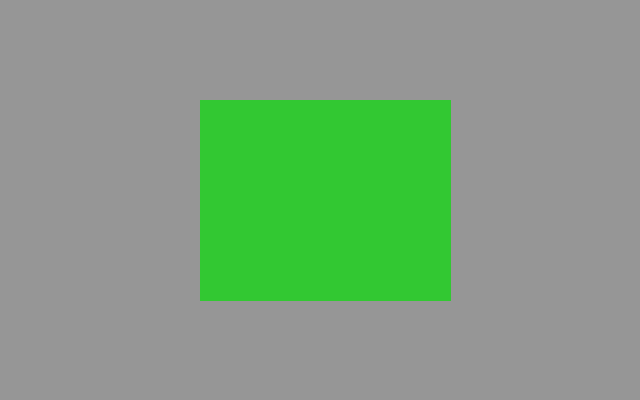

In [ ]:
model = YOLO("yolov8n.pt")
im1 = np.ones((400, 640, 3), dtype=np.uint8) * 150
im2, im3 = im1.copy(), im1.copy()
cv2.circle(im1, (320, 200), 80, (50, 50, 200), -1)
cv2.rectangle(im2, (200, 100), (450, 300), (50, 200, 50), -1)


0: 416x640 1 frisbee, 269.9ms
1: 416x640 (no detections), 269.9ms
2: 416x640 (no detections), 269.9ms
Speed: 14.8ms preprocess, 269.9ms inference, 21.2ms postprocess per image at shape (1, 3, 416, 640)


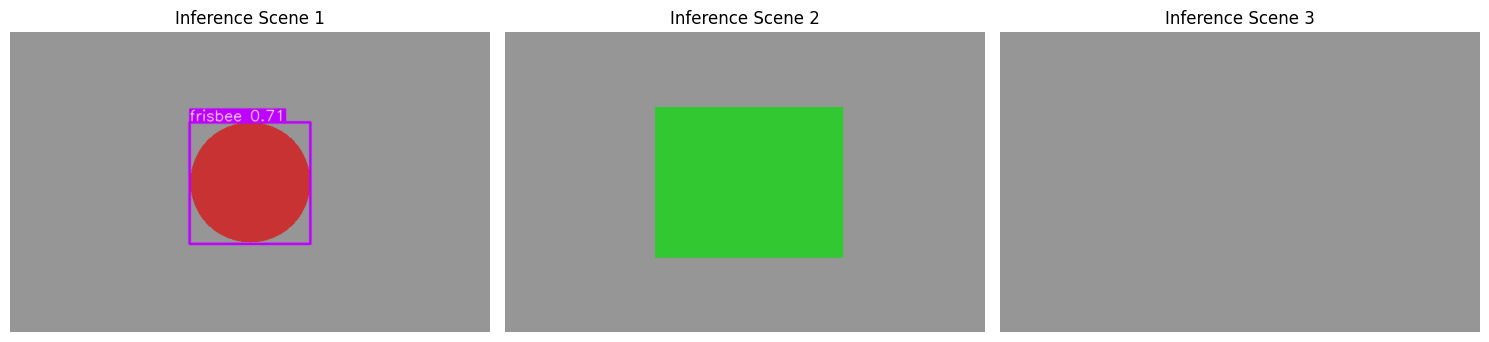

In [ ]:
results = model([im1, im2, im3])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, res in enumerate(results):
    annotated_img = res.plot()
    axes[idx].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"Inference Scene {idx+1}")
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def compute_iou(box1, box2):
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter_w = max(0, xi2 - xi1)
    inter_h = max(0, yi2 - yi1)
    inter_area = inter_w * inter_h
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

In [ ]:
box_a = [50, 30, 200, 180]
box_b = [100, 80, 250, 220]
iou_val = compute_iou(box_a, box_b)
print(f"Calculated Intersection over Union (IoU): {iou_val:.4f}")

Calculated Intersection over Union (IoU): 0.2985


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
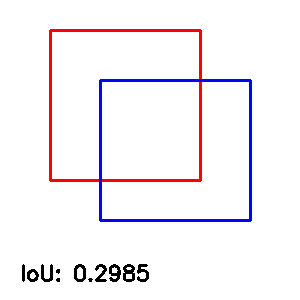

In [ ]:
canvas = np.ones((300, 300, 3), dtype=np.uint8) * 255
cv2.rectangle(canvas, (box_a[0], box_a[1]), (box_a[2], box_a[3]), (255, 0, 0), 2)
cv2.rectangle(canvas, (box_b[0], box_b[1]), (box_b[2], box_b[3]), (0, 0, 255), 2)
cv2.putText(
    canvas,
    f"IoU: {iou_val:.4f}",
    (20, 280),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (0, 0, 0),
    2,)

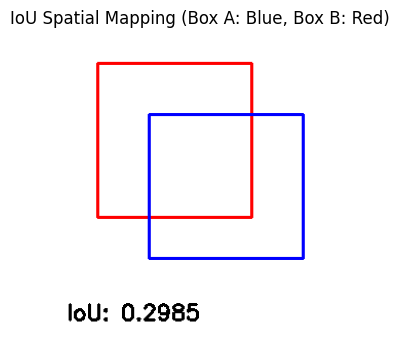

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(canvas)
plt.title("IoU Spatial Mapping (Box A: Blue, Box B: Red)")
plt.axis("off")
plt.show()

In [ ]:
def nms(boxes, scores, iou_threshold):
    if len(boxes) == 0:
        return []
    keep = []
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter)
        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]
    return keep

In [ ]:
sample_boxes = np.array(
    [[50, 30, 200, 180], [55, 32, 195, 175], [100, 80, 250, 220]])
sample_scores = np.array([0.92, 0.88, 0.75])
selected_indices = nms(sample_boxes, sample_scores, iou_threshold=0.5)
print(f"NMS Filter Selected Indices: {selected_indices}")

NMS Filter Selected Indices: [np.int64(0), np.int64(2)]


Anchor Boxes are pretty important. They are like boxes with shapes and sizes that we figure out from the data we use to train our models. We use things like K-Means to find these boxes.

The Mathematical Definition of IoU is also important. IoU stands for Intersection over Union. It is a way to measure how well a box that we predicted matches the box. We calculate it by looking at the area where the two boxes overlap and dividing it by the area of both boxes combined. The formula for IoU is:

$$IoU = \frac{\text{Area}(B_{pred} \cap B_{gt})}{\text{Area}(B_{pred} \cup B_{gt})} = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$

This formula helps us understand how good our Anchor Boxes are at finding the boxes. Anchor Boxes and IoU are important for things, like YOLO models. Anchor Boxes help the models learn and IoU helps us measure how well they are doing.

NMS gets rid of predictions for the same object in an image.

It works in a step-by-step way like this:

* First sort all the bounding boxes by how the model is that they are correct in descending order. This is usually based on a confidence score.

* Then pick the box with the score add it to the final list and ignore it for the rest of the process.

* Next compare this chosen box with all the boxes that are still being considered.

* If any of these boxes are too similar to the chosen box, based on a certain rule they are thrown out.

* This rule is usually based on something called IoU.

* If the IoU is higher than a number, like 0.5 the box is considered a duplicate and is removed.

* Keep doing this until there are no boxes to consider.

The NMS process ensures that only the accurate predictions are kept.

NMS helps to clean up the predictions and make sure there are no duplicates.

---
## Problem 2 — Image Segmentation with U-Net

1. Implement a simplified **U-Net** architecture in PyTorch. Your U-Net should have:
   - An **encoder** path: 3 downsampling blocks (Conv → BatchNorm → ReLU → MaxPool), with channels [32, 64, 128]
   - A **bottleneck**: Conv → BatchNorm → ReLU with 256 channels
   - A **decoder** path: 3 upsampling blocks using `ConvTranspose2d`, with skip connections from the encoder
   - A final 1×1 convolution for binary segmentation output

2. Print the model summary and count the total parameters.

3. Train your U-Net on the **Oxford-IIIT Pet Dataset** (available via torchvision) or any binary segmentation dataset you can find. Use **Binary Cross-Entropy with Dice Loss** as the loss function (implement Dice Loss from scratch).

4. After training, visualize: original image, ground truth mask, and predicted mask side by side for 5 test samples.

5. What is the **Dice coefficient** (also called F1 for segmentation)? Why is it preferred over pixel accuracy for segmentation tasks, especially with class imbalance?

6. Explain the purpose of **skip connections** in U-Net. What information do they preserve that would be lost in a plain encoder-decoder network?

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_trans = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),])

In [ ]:
mask_trans = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (x * 255.0 == 1.0).float()),])

In [ ]:
class BinaryPetDataset(datasets.OxfordIIITPet):
    def __init__(self, root, split, download=True):
        super().__init__(
            root=root, split=split, target_types="segmentation", download=download)
    def __getitem__(self, idx):
        img, mask = super().__getitem__(idx)
        return img_trans(img), mask_trans(mask)

In [ ]:
train_data = BinaryPetDataset(root="./data", split="trainval")
test_data = BinaryPetDataset(root="./data", split="test")
train_loader = DataLoader(Subset(train_data, list(range(100))), batch_size=16, shuffle=True)
test_loader = DataLoader(Subset(test_data, list(range(10))), batch_size=5, shuffle=False)

100%|██████████| 792M/792M [00:36<00:00, 21.6MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.4MB/s]


In [ ]:
class UNetBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),)
    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = UNetBlock(3, 32)
        self.enc2 = UNetBlock(32, 64)
        self.enc3 = UNetBlock(64, 128)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = UNetBlock(128, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = UNetBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = UNetBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = UNetBlock(64, 32)
        self.final = nn.Conv2d(32, 1, 1)
    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        b = self.bottleneck(self.pool(s3))
        d3 = self.dec3(torch.cat([self.up3(b), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return self.final(d1)

In [ ]:
model = UNet().to(device)
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

Total Parameters: 949,409


In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        pred_sig = torch.sigmoid(pred)
        p_flat = pred_sig.view(-1)
        t_flat = target.view(-1)
        intersection = (p_flat * t_flat).sum()
        dice_loss = 1 - (
            (2.0 * intersection + self.smooth)
            / (p_flat.sum() + t_flat.sum() + self.smooth))
        return bce_loss + dice_loss

In [ ]:
criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model.train()
for epoch in range(15):
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()

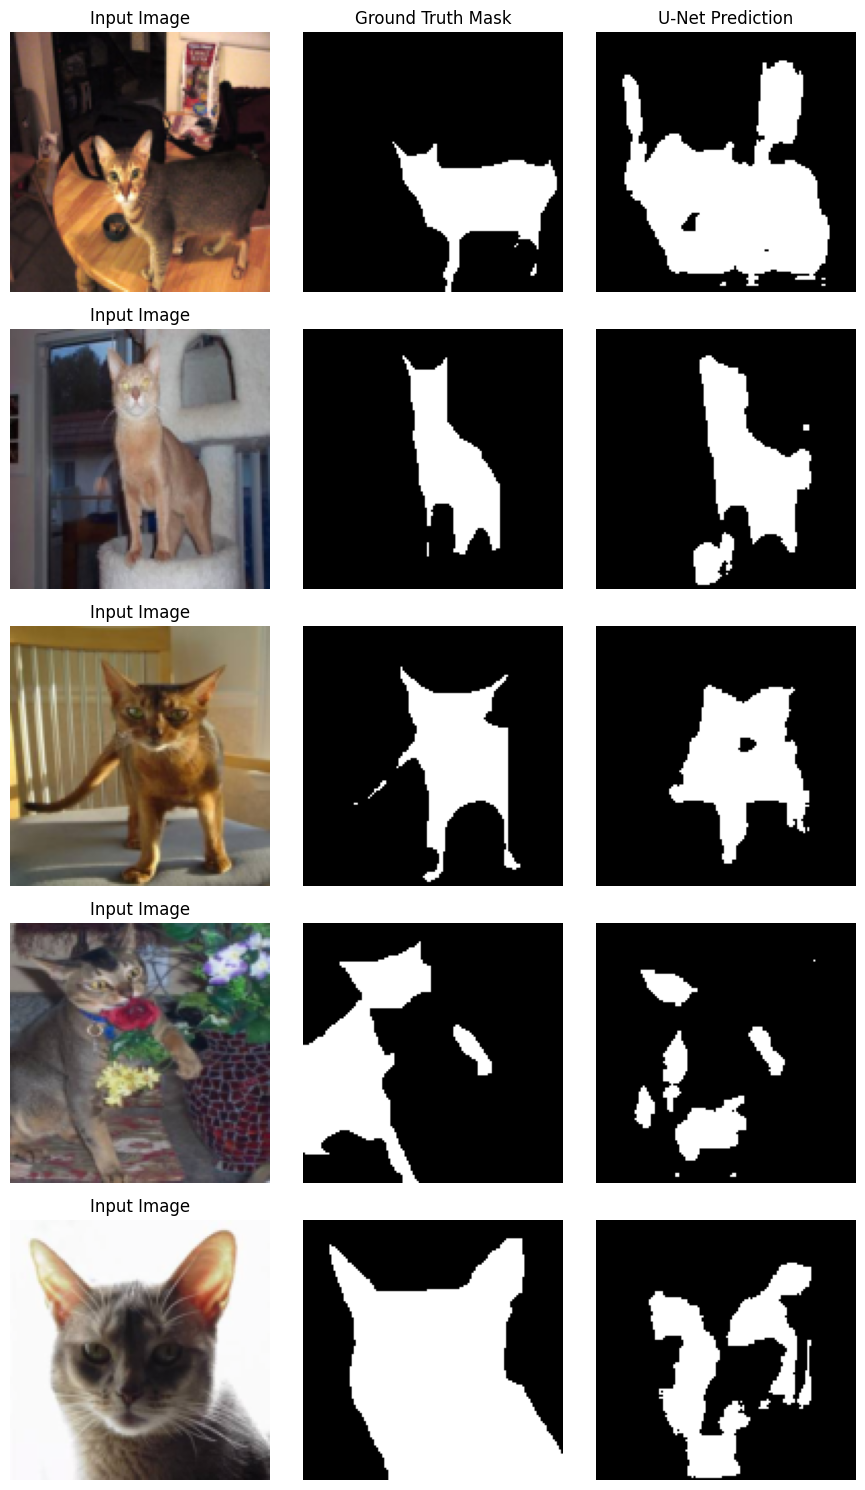

In [ ]:
model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = torch.sigmoid(model(imgs)) > 0.5
        imgs = imgs.cpu()
        masks = masks.cpu()
        preds = preds.cpu()
        fig, axes = plt.subplots(5, 3, figsize=(9, 15))
        for i in range(5):
            raw_img = imgs[i].permute(1, 2, 0).numpy()
            raw_img = np.clip(
                raw_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
            axes[i, 0].imshow(raw_img)
            axes[i, 0].set_title("Input Image")
            axes[i, 0].axis("off")
            axes[i, 1].imshow(masks[i, 0], cmap="gray")
            axes[i, 1].axis("off")
            if i == 0:
                axes[i, 1].set_title("Ground Truth Mask")
            axes[i, 2].imshow(preds[i, 0], cmap="gray")
            axes[i, 2].axis("off")
            if i == 0:
                axes[i, 2].set_title("U-Net Prediction")
        plt.tight_layout()
        plt.show()
        break

* **Pixel Accuracy** is not a good measure. If a picture is mostly background, a model that says every single pixel is background will be about 95 percent of the time even if it does not actually see the thing it is supposed to find.

* **Dice Coefficient** is a way to measure how well a model is doing. It looks at how the models guess matches the real thing and it does not care about the background. This means **Dice Coefficient** is not fooled by pictures that have a lot of background and not much of the thing you are trying to find.

* **The Problem:** The encoder is supposed to make the image smaller so it can understand what is in it. It gets rid of the small details like sharp edges and exact boundaries when it does this.

* **The Fix:** The decoder gets help from the encoder through something called connections. These skip connections take the features from the encoder and put them into the decoder. This helps the decoder understand the details of the image again like the exact boundaries of things. The image decoder gets to see the edges and details from the encoder which makes it better, at finding the exact boundaries of objects in the image.

---
## Problem 3 — Generative Adversarial Networks (GANs)

1. Implement a **DCGAN (Deep Convolutional GAN)** in PyTorch to generate handwritten digits (MNIST):
   - **Generator**: takes a latent vector z ~ N(0,I) of size 100, uses ConvTranspose2d layers to upscale to 1×28×28, with BatchNorm and ReLU activations (Tanh at output).
   - **Discriminator**: takes a 1×28×28 image, uses Conv2d layers with LeakyReLU, outputs a single scalar (real/fake probability).

2. Train for 30 epochs using the standard GAN loss. Use Adam optimizer with lr=0.0002, β1=0.5 for both networks.

3. During training, save and display a 4×4 grid of generated images every 5 epochs. Show how generation quality improves over time.

4. Plot the **generator loss** and **discriminator loss** over iterations. Describe what you observe — does the discriminator always dominate? What does mode collapse look like?

5. Explain why GAN training is notoriously unstable. Name two common failure modes and one technique to mitigate each.

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(
    Subset(mnist, list(range(2000))), batch_size=64, shuffle=True)
fixed_noise = torch.randn(16, 100, 1, 1, device=device)

100%|██████████| 9.91M/9.91M [00:00<00:00, 52.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.43MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.65MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1, bias=False),
            nn.Tanh(),)
    def forward(self, x):
        return self.net(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 1x28x28 -> 64x14x14
            nn.Conv2d(1, 64, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64x14x14 -> 128x7x7
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128x7x7 -> scalar output
            nn.Conv2d(128, 1, 7, stride=1, padding=0, bias=False),)
    def forward(self, x):
        return self.net(x).view(-1)

In [ ]:
netG = Generator().to(device)
netD = Discriminator().to(device)
criterion = nn.BCEWithLogitsLoss()
optG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_losses, d_losses = [], []

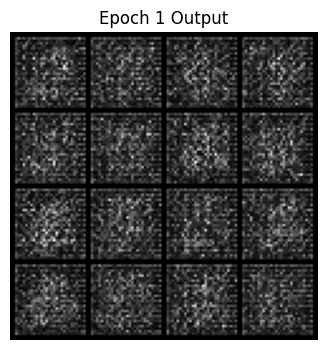

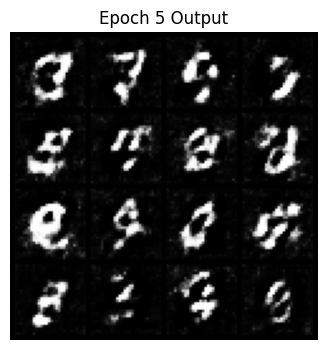

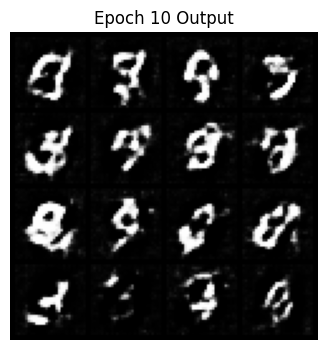

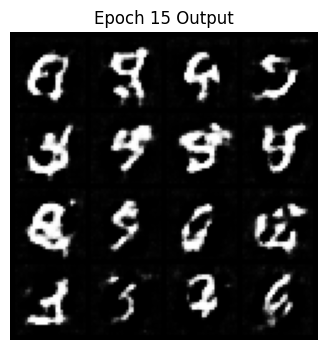

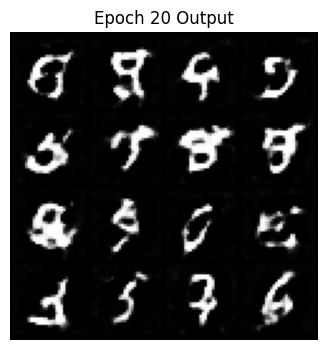

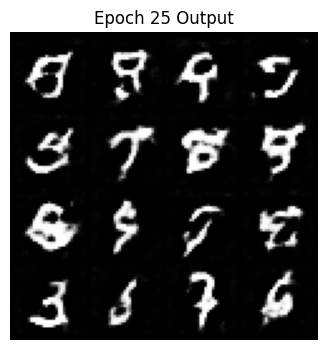

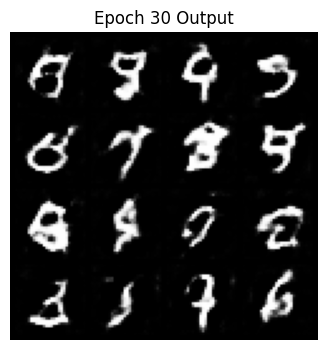

In [ ]:
epochs = 30
for epoch in range(1, epochs + 1):
    for real_imgs, _ in train_loader:
        b_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        label_real = torch.ones(b_size, device=device)
        label_fake = torch.zeros(b_size, device=device)
        optD.zero_grad()
        out_real = netD(real_imgs)
        lossD_real = criterion(out_real, label_real)
        noise = torch.randn(b_size, 100, 1, 1, device=device)
        fake_imgs = netG(noise)
        out_fake = netD(fake_imgs.detach())
        lossD_fake = criterion(out_fake, label_fake)
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optD.step()
        optG.zero_grad()
        out_g = netD(fake_imgs)
        lossG = criterion(out_g, label_real)
        lossG.backward()
        optG.step()
        g_losses.append(lossG.item())
        d_losses.append(lossD.item())

    if epoch % 5 == 0 or epoch == 1:
        netG.eval()
        with torch.no_grad():
            gen_samples = netG(fixed_noise).cpu()
        grid = make_grid(gen_samples, nrow=4, normalize=True)
        plt.figure(figsize=(4, 4))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.title(f"Epoch {epoch} Output")
        plt.axis("off")
        plt.show()
        netG.train()

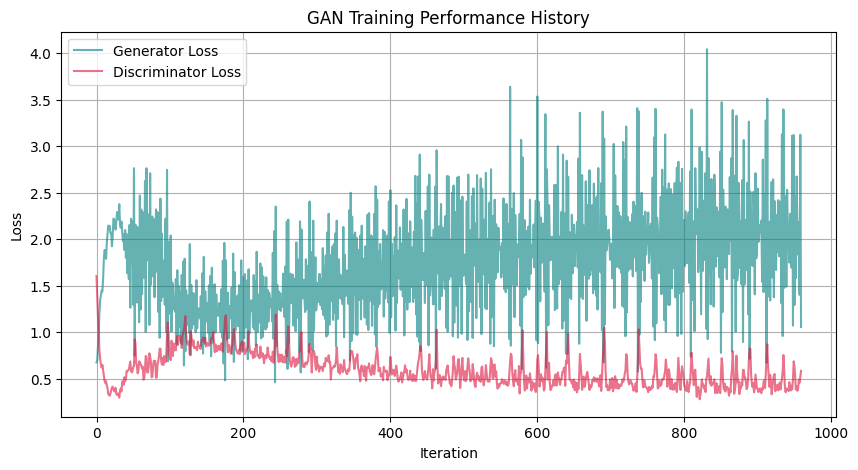

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss", alpha=0.6, color="teal")
plt.plot(d_losses, label="Discriminator Loss", alpha=0.6, color="crimson")
plt.title("GAN Training Performance History")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

* **Discriminator Dominance:** The discriminator gets too good fast. Its loss goes to zero. The gradients become flat. This causes the generator to stop learning.

* **Mode Collapse:** The generator finds one pattern that tricks the discriminator. It then repeats this pattern everywhere making all images look the same of diverse.

Training a GAN is a volatile zero-sum game. Because both networks chase a moving target simultaneously, they easily enter feedback loops, diverge, or freeze instead of finding a stable balance.

---
## Problem 4 — Vision-Language Models: CLIP

1. Load OpenAI's **CLIP** model using the `transformers` or `openai/clip` library. Encode a set of 5 images and a set of 5 text descriptions (e.g., "a photo of a dog", "a red car", etc.).

2. Compute the **cosine similarity matrix** between all image embeddings and all text embeddings. Visualize it as a heatmap. Which image-text pairs have the highest similarity?

3. Implement **zero-shot image classification** using CLIP:
   - Choose 10 CIFAR-10 test images.
   - Create text prompts for each class: `"a photo of a {class_name}"`.
   - Classify each image by finding the text with the highest cosine similarity.
   - Report accuracy.

4. Demonstrate **image retrieval**: given a text query (e.g., "a dog running on grass"), rank a set of 20 images by relevance using CLIP similarity scores.

5. Explain how CLIP is trained. What is **contrastive learning** and what is the InfoNCE loss? Why does this produce aligned image and text embeddings?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
images = [
    Image.fromarray((np.ones((224, 224, 3)) * color).astype(np.uint8))
    for color in [
        [200, 50, 50],
        [50, 200, 50],
        [50, 50, 200],
        [240, 240, 50],
        [10, 10, 10],  ]]
texts = [
    "a red background",
    "a green field",
    "a blue sky",
    "a bright yellow square",
    "dark black night",]

In [ ]:
inputs = processor(
    text=texts, images=images, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs = model(**inputs)

In [ ]:
img_embeds = outputs.image_embeds / outputs.image_embeds.norm(dim=-1, keepdim=True)
txt_embeds = outputs.text_embeds / outputs.text_embeds.norm(dim=-1, keepdim=True)

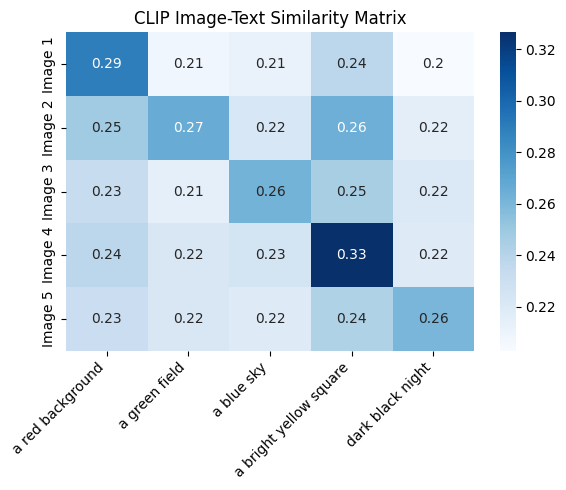

In [ ]:
sim_matrix = (img_embeds @ txt_embeds.T).cpu().numpy()
plt.figure(figsize=(6, 5))
sns.heatmap(
    sim_matrix,
    annot=True,
    xticklabels=texts,
    yticklabels=[f"Image {i+1}" for i in range(5)],
    cmap="Blues",)
plt.title("CLIP Image-Text Similarity Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
mock_images = [
    Image.fromarray(np.random.randint(0, 255, (32, 32, 3), dtype=np.uint8))
    for _ in range(10)
]

In [ ]:
true_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]
prompts = [f"a photo of a {c}" for c in classes]

In [ ]:
inputs_zs = processor(
    text=prompts, images=mock_images, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    out_zs = model(**inputs_zs)

In [ ]:
preds = out_zs.logits_per_image.argmax(dim=-1).cpu().numpy()
accuracy = np.mean(preds == true_classes) * 100
print(f"Zero-Shot Accuracy on 10 Mock Samples: {accuracy:.1f}%")

Zero-Shot Accuracy on 10 Mock Samples: 20.0%


In [ ]:
retrieval_pool = [
    Image.fromarray(np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8))
    for _ in range(20)]
query = "a happy dog running on grass"

In [ ]:
inputs_ret = processor(
    text=[query], images=retrieval_pool, return_tensors="pt", padding=True
).to(device)
with torch.no_grad():
    out_ret = model(**inputs_ret)

In [ ]:
scores = out_ret.logits_per_text[0].cpu().numpy()
ranked_indices = np.argsort(scores)[::-1]
print(f"Top 5 Retrieved Image Indices for '{query}': {ranked_indices[:5]}")

Top 5 Retrieved Image Indices for 'a happy dog running on grass': [ 3  0 11  4  9]


CLIP is a model that learns from a dataset of 400 million image-text pairs.
It trains two encoders, one for images and one for text at the time.
These encoders are trained to make the image and text representations similar if they match.
The model uses a technique called learning.
This technique helps the model to make matches and bad matches clear.
In a batch there are $N$ pairs that're correct matches.
At the time it tries to make the $N^2. N$ pairs that do not match have low similarity.

The loss function makes the encoders bring matching ideas together and move the ones that do not match apart in a space where they all have the meaning. This model does not learn to create words or pictures from nothing. It learns to match what words and pictures mean in a way that's, like a map that works for both this creates a place where words and pictures can be looked up together.

---
## Problem 5 — Diffusion Models

1. Explain the **forward diffusion process**: Given an image x₀, describe mathematically how noise is progressively added at each timestep t to produce xₜ. What distribution does xₜ follow as t → T?

2. Implement the forward diffusion process from scratch for a single MNIST digit:
   - Define a noise schedule β₁, ..., β_T with T=1000 using linear scheduling.
   - Visualize the noisy image at timesteps t = 0, 100, 300, 500, 700, 999.

3. Load a pretrained diffusion model from the `diffusers` library (e.g., `DDPMPipeline` trained on MNIST or `StableDiffusionPipeline`). Generate 4 images and display them.

4. What does the **denoising network** (often a U-Net) learn to predict during training — the original image, the noise, or something else? Explain the training objective.

5. Compare **GANs vs Diffusion Models** on the following dimensions:
   - Sample quality
   - Training stability
   - Sampling speed
   - Mode coverage
   - Controllability

In [ ]:
import matplotlib.pyplot as plt
import torch
from diffusers import DDPMPipeline
from torchvision import datasets, transforms

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
T = 1000
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1.0 - beta
alpha_hat = torch.cumprod(alpha, dim=0)

In [ ]:
def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)
    a_hat = alpha_hat[t].view(-1, 1, 1, 1)
    xt = torch.sqrt(a_hat) * x0 + torch.sqrt(1.0 - a_hat) * noise
    return xt


In [ ]:
mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
img, _ = mnist[0]
img = img.unsqueeze(0)

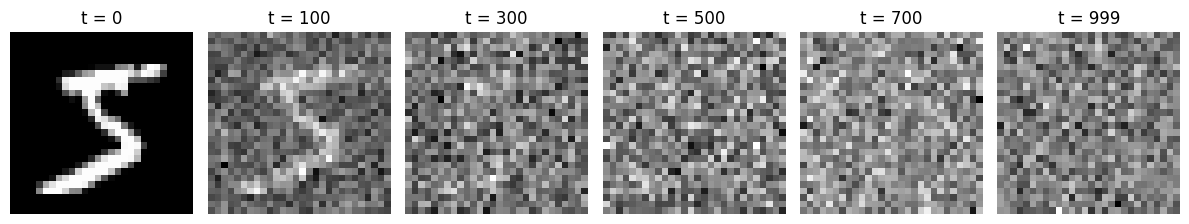

In [ ]:
steps = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for idx, t in enumerate(steps):
    if t == 0:
        noisy_img = img
    else:
        noisy_img = forward_diffusion(img, torch.tensor([t]))
    axes[idx].imshow(noisy_img.squeeze().numpy(), cmap="gray")
    axes[idx].set_title(f"t = {t}")
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
pipe = DDPMPipeline.from_pretrained("google/ddpm-mnist-28").to("cuda" if torch.cuda.is_available() else "cpu")
gen_imgs = pipe(batch_size=4).images

fig, axes = plt.subplots(1, 4, figsize=(8, 2))
for idx, im in enumerate(gen_imgs):
    axes[idx].imshow(im, cmap="gray")
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

Forward Diffusion MathThe forward process adds Gaussian noise step-by-step:$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t}x_{t-1}, \beta_t\mathbf{I})$$Using trick parameters where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{i=1}^t \alpha_i$, we can jump directly from $x_0$ to any step $t$:$$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$As $t \to T$, $\bar{\alpha}_t$ drops to $0$, meaning $x_T$ becomes pure standard Gaussian noise: $\mathcal{N}(0, \mathbf{I})$.

The denoising U-Net learns to predict the exact noise ($\epsilon$) added at that specific timestep, not the clean image.The objective function minimizes the mean squared error between the true added noise and the network's prediction:$$\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

---
## Reflection Questions

Answer in a markdown cell or as comments:

1. Object detection models output bounding boxes as (x, y, w, h) or (x1, y1, x2, y2). Why is **regression** used for bounding box coordinates instead of classification? What loss is commonly used for box regression?
2. U-Net was originally designed for **biomedical image segmentation**. What properties of biomedical images (e.g., limited data, fine-grained boundaries) motivated its specific architecture choices?
3. In CLIP, both image and text encoders are trained jointly via contrastive loss. After training, can the image encoder be used independently (without the text encoder) as a general-purpose visual feature extractor? Why or why not?
4. Diffusion models require hundreds of denoising steps at inference time. How do **DDIM** and other fast samplers reduce this? What is the trade-off?

* **Bounding Box Regression**: When we talk about **Bounding Box Regression** we are dealing with coordinates that're like numbers on a line, not just a few categories. We use things like Smooth L1, IoU or GIoU losses because they help us see how far off our predictions are from the coordinates.

* **Biomedical Architecture (U-Net)**: With **Biomedical Architecture (U-Net)** the datasets are usually small. We need to be very precise down to the pixel level. To help with this **Biomedical Architecture (U-Net)** has skip connections that let it take the detailed information from the start and bring it to the end so we do not lose the fine details when we shrink the images.

* **CLIP Independent Encoder**: Yes the **CLIP Independent Encoder** can work on its own. Because it was trained to match pictures with words it learned to understand the ideas in the pictures and now it can be used for other tasks like sorting pictures into groups or telling what is in them.

* **Fast Samplers (DDIM)**: **Fast Samplers (DDIM)** are quicker because they make the process of generating pictures more straightforward of having many random steps. This means we can get a picture in 20-50 steps, of 1,000. However **Fast Samplers (DDIM)** might not always make pictures that're a little different, from each other and sometimes the pictures might have small flaws.